In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
import xarray as xr
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import numpy.ma as ma
import gsw
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from legendkit import legend
from legendkit.layout import vstack, hstack
from skimage import measure

In [2]:
def find_nearest(array_x, value_x):
    idx = np.sqrt((array_x - value_x)**2).argmin()
    return idx
   
def calc_cont(ssh, lon_start, lat_start, y_fin, N_smooth_cont, N_smooth_der):

    # contour search algorithm adjusted for calculating with xarray format from averaged isopycnals instead of instantaneous ones.
    
    ssh = ssh.T # coordinate axes convenience
    contours = measure.find_contours(ssh.values, 0)
    # print(I, len(contours))
    
    len_cont = [np.shape(contours[i])[0] for i in range(len(contours))]
    ind = (len_cont - np.max(len_cont)).argmax()
    #contour_coors = contours[ind][::-1,:]
    
    lat_gulf = 30
    lon_gulf = -80
    d_min = np.zeros(len(contours))
    
    lat_mod = ssh.y.values
    lon_mod = ssh.x.values
    
    for i in range(len(contours)):
        d = np.zeros(len(contours[i][:,0]))
        for j in range(len(contours[i][:,0])):
            len_cont = [np.shape(contours[i])[0] for i in range(len(contours))]
    
            lat_t = contours[i][j,1]/np.shape(ssh)[0]*(lat_mod[-1] - lat_mod[0]) + lat_mod[0]
            lon_t = contours[i][j,0]/np.shape(ssh)[1]*(lon_mod[-1] - lon_mod[0]) + lon_mod[0]
            d[j] = (lat_t - lat_gulf)**2 + (lon_t - lon_gulf)**2
        d_min[i] = d.min()
    
    ind = d_min.argmin()
    contour_coors = contours[ind] #[::-1,:]
    
    lat = contour_coors[:,1]/np.shape(ssh)[1]*(lat_mod[-1] - lat_mod[0]) + lat_mod[0]
    lon = contour_coors[:,0]/np.shape(ssh)[0]*(lon_mod[-1] - lon_mod[0]) + lon_mod[0]
    # plt.pcolormesh(lon_mod, lat_mod, ssh.T)
    # plt.plot(lon, lat)
    # plt.show()
    # smoothen contour
    dx_shift = (lon[2:] - lon[:-2])/2/180*np.pi*np.cos(lat[1:-1]/180*np.pi)*R
    dy_shift = (lat[2:] - lat[:-2])/2/180*np.pi*R
    dy = np.sqrt(dx_shift**2 + dy_shift**2)
    
    lat = np.convolve(lat[1:-1]*dy, np.ones(N_smooth_cont), mode = 'valid') / np.convolve(dy, np.ones(N_smooth_cont), mode = 'valid')
    lon = np.convolve(lon[1:-1]*dy, np.ones(N_smooth_cont), mode = 'valid') / np.convolve(dy, np.ones(N_smooth_cont), mode = 'valid')

    # calculate arclength and orthogonal vectors 
    N = len(lat)
    t_vec = np.zeros([N-1, 2]) # vector to hold orthogonal directions
    dx_shift = (lon[1:] - lon[:-1])/180*np.pi*np.cos(lat[:-1]/180*np.pi)*R
    dy_shift = (lat[1:] - lat[:-1])/180*np.pi*R
    dy = np.sqrt(dx_shift**2 + dy_shift**2)
    t_vec[:,0] = dy_shift/dy # t_vec holdy the vector orthogonal to the path in local cartesian coordinates
    t_vec[:,1] = -dx_shift/dy 
    y = np.cumsum(dy)

    # smoothen orthogonal vector
    t_vec_smooth = np.zeros([N-N_smooth_der,2])
    t_vec_smooth[:,0] = np.convolve(t_vec[:,0]*dy, np.ones(N_smooth_der), mode = 'valid') / np.convolve(dy, np.ones(N_smooth_der), mode = 'valid')
    t_vec_smooth[:,1] = np.convolve(t_vec[:,1]*dy, np.ones(N_smooth_der), mode = 'valid') / np.convolve(dy, np.ones(N_smooth_der), mode = 'valid')
    t_vec = t_vec_smooth

    # cut other vectors accordingly
    y = y[int(N_smooth_der/2):-int(N_smooth_der/2)]
    dy = dy[int(N_smooth_der/2):-int(N_smooth_der/2)]
    lon = lon[int(N_smooth_der/2):-int(N_smooth_der/2)]
    lat = lat[int(N_smooth_der/2):-int(N_smooth_der/2)]

    # calculate radius of curvature along central axis to avoid taking averages where local coordinates system is not well posed
    dx_shift = (lon[1:] - lon[:-1])/180*np.pi*np.cos(lat[:-1]/180*np.pi)*R # calculate distance in local cartesian differentials
    dy_shift = (lat[1:] - lat[:-1])/180*np.pi*R
    curvature = ((dy_shift*t_vec[1:,0] - dx_shift*t_vec[1:,1])/(t_vec[:-1,1]*t_vec[1:,0] - t_vec[:-1,0]*t_vec[1:,1]))

    # cut other vectors accordingly
    t_vec = t_vec[:-1,:]
    y = y[:-1]
    lon = lon[:-1]
    lat = lat[:-1]

    # smoothen inverse curvature
    curv_smooth = np.zeros([N-N_smooth_der])
    curv_inv_smooth = np.convolve(1/curvature*dy, np.ones(N_smooth_der), mode = 'valid') / np.convolve(dy, np.ones(N_smooth_der), mode = 'valid')
    curvature = 1/curv_inv_smooth

    # cut other vectors accordingly
    y = y[int(N_smooth_der/2):-int(N_smooth_der/2)]
    lon = lon[int(N_smooth_der/2):-int(N_smooth_der/2)]
    lat = lat[int(N_smooth_der/2):-int(N_smooth_der/2)]
    t_vec = t_vec[int(N_smooth_der/2):-int(N_smooth_der/2)]
    
    # find starting index
    idx_start = find_nearest(lon, lon_start)
    d = np.zeros(len(lon))
    for j in range(len(lon)):
        lat_t = lat[j]
        lon_t = lon[j]
        d[j] = (lat_t - lat_start)**2 + (lon_t - lon_start)**2

    idx_start = d.argmin()
    # find ending index
    #idx_end = find_nearest(lon[:2000], lon_end)
    
    # cut vectors
    lat_cont = lat[idx_start:]#idx_end]
    lon_cont = lon[idx_start:]#idx_end]
    t_vec = t_vec[idx_start:]#idx_end]
    y = y[idx_start:] - y[idx_start]
    curvature = curvature[idx_start:]

    # cut array to specific arclength
    ii = find_nearest(y, y_fin)
    
    lon_cont = lon_cont[:ii]
    lat_cont = lat_cont[:ii]
    t_vec = t_vec[:ii]
    y = y[:ii]
    curvature = curvature[:ii]
    
    return lon_cont, lat_cont, t_vec, y, curvature

In [3]:
# calculate mean temperature and salinity fields from LEVITUS dataset. (not included in this repository, consult paper on how to access)

# open temperature data
savedir = "../../../../SW/project_simple_param_space/LEVITUS/"
filename = "otemp.hr.annltm.nc"
ds = xr.open_dataset(savedir + filename)
T_fine = ds["otemp"][0,:,:,:]

# open salinity data
filename = "salt.hr.annltm.nc"
ds = xr.open_dataset(savedir + filename)
S_fine = ds["salt"][0,:,:,:]

/home/lennard/miniconda3/envs/DA/lib/python3.12/site-packages/xarray/coding/times.py:167: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:0.0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:0.0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  warnings.warn(warning_msg, SerializationWarning)
/home/lennard/miniconda3/envs/DA/lib/python3.12/site-packages/xarray/coding/times.py:832: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/home/lennard/miniconda3/envs/DA/lib/python3.12/site-packages/xarray/core/indexing.py:560: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.dateti

In [4]:
# calculate maps

S = S_fine.coarsen(lat = 1, lon = 1).mean()
T = T_fine.coarsen(lat = 1, lon = 1).mean()

z = S.level.values
P = 1e3*9.81*z/1e4 

CT = gsw.CT_from_t(S, T, P[:,None,None])
drho = gsw.density.sigma0(S, CT)

In [5]:
# Calculate example stratification over Gulf Stream region, defined by the polygon spanned by these four points.

lon_p1 = -79.999 + 360
lat_p1 = 32

lon_p2 = -80 + 360
lat_p2 = 26

lon_p3 = -68 + 360
lat_p3 = 38

lon_p4 = -68 + 360
lat_p4 = 44

def custom_condition3(data_array, lat_p1, lon_p1, lat_p2, lon_p2):
    # area selection condition for data_array format
    return (data_array.lat - lat_p1)/(lat_p2 - lat_p1) > (data_array.lon - lon_p1)/(lon_p2 - lon_p1)

def custom_condition4(lat, lon, lat_p1, lon_p1, lat_p2, lon_p2):
    # area selection condition for latitude/longitude arrays
    return (lat - lat_p1)/(lat_p2 - lat_p1) > (lon - lon_p1)/(lon_p2 - lon_p1)
    
da = S_fine
selected_da = da.where(custom_condition3(da, lat_p1, lon_p1, lat_p2, lon_p2))
selected_da = selected_da.where(custom_condition3(da, lat_p4, lon_p4, lat_p3, lon_p3))
selected_da = selected_da.where(custom_condition3(da, lat_p2, lon_p2, lat_p3, lon_p3))
selected_da = selected_da.where(custom_condition3(da, lat_p4, lon_p4, lat_p1, lon_p1))
S_gulf = selected_da

da = T_fine
selected_da = da.where(custom_condition3(da, lat_p1, lon_p1, lat_p2, lon_p2))
selected_da = selected_da.where(custom_condition3(da, lat_p4, lon_p4, lat_p3, lon_p3))
selected_da = selected_da.where(custom_condition3(da, lat_p2, lon_p2, lat_p3, lon_p3))
selected_da = selected_da.where(custom_condition3(da, lat_p4, lon_p4, lat_p1, lon_p1))
T_gulf = selected_da

z = S.level.values
P = 1e3*9.81*z/1e4

CT = gsw.CT_from_t(S_gulf, T_gulf, P[:,None,None])
drho_gulf = gsw.density.sigma0(S_gulf, CT)

drho_gulf_m = np.nanmean(drho_gulf, axis = (-2, -1))
z = -drho_gulf.level

/tmp/ipykernel_8885/1059541218.py:43: RuntimeWarning: Mean of empty slice
  drho_gulf_m = np.nanmean(drho_gulf, axis = (-2, -1))


In [6]:
# Basilisk configuration

rho0 = 1000
basilisk_strat =  np.array([ 2.13/rho0, 1.72/rho0, 1.41/rho0, 1.01/rho0, 0. ])
basilisk_strat = basilisk_strat[::-1] - basilisk_strat[0]

/tmp/ipykernel_8885/1547250364.py:56: RuntimeWarning: invalid value encountered in divide
  t_vec[:,0] = dy_shift/dy # t_vec holdy the vector orthogonal to the path in local cartesian coordinates
/tmp/ipykernel_8885/1547250364.py:57: RuntimeWarning: invalid value encountered in divide
  t_vec[:,1] = -dx_shift/dy


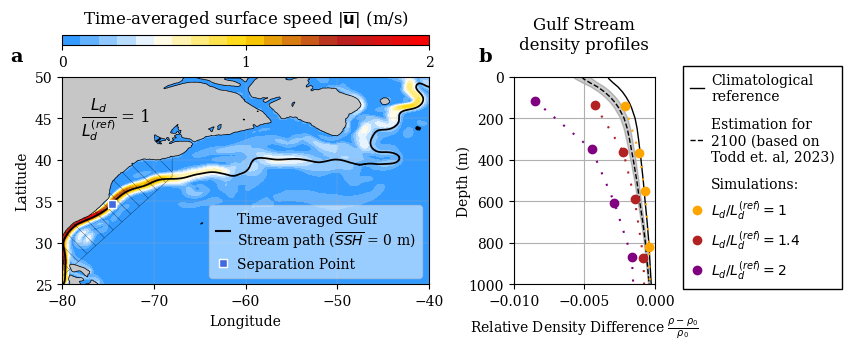

In [8]:
path = "Data/"

# bounds for displayed area in fig 1a.
lat_min = 25
lat_max = 50
lon_min = -80
lon_max = -40

drho_facs = [1, 2, 4]

plt.rcParams['font.family'] = 'serif'

fig = plt.figure(figsize=(8.5*0.9, 3*0.9))
grid = plt.GridSpec(1, 3, hspace=0.1, wspace=0.6)

cs = ["dodgerblue", "white", "gold", "firebrick", "red"]
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("cmap_name", cs)

Rd_labels = ["1", "1.4", "2"]
labels = ["a", "b", "c"]
R0 = 39066.430787677964

drho_fac = 1

drho = np.array([ 2.13, 1.72, 1.41, 1.01, 0. ])[::-1]*drho_fac

# open datasets

# topo mask 
ds_topo = xr.open_dataset(path + "topo.nc")
topo = ds_topo["zb"][0,:,:,:].transpose("y", "x", "level")
mask = topo < 0
mx = ma.masked_array(np.zeros(np.shape(topo)), mask=mask)
zeros = topo*0
   
# us
us_ds = xr.open_dataset(path + "gulf_" + str(drho_fac) + "drho_u_mean.nc", decode_times=False)
ums = us_ds["u.x"].transpose("y", "x", "level")
lon_mod = ums.x
lat_mod = ums.y
usv = ums.values
usv[topo > 0] = np.nan
ums.values = usv

# vs
vs_ds = xr.open_dataset(path + "gulf_" + str(drho_fac) + "drho_v_mean.nc", decode_times=False)
vms = vs_ds["u.y"].transpose("y", "x", "level")
vsv = vms.values
vsv[topo > 0] = np.nan
vms.values = vsv

# isopycs
isopycs_ds = xr.open_dataset(path + "gulf_" + str(drho_fac) + "drho_isopycs_mean.nc", decode_times=False)
isopycs = isopycs_ds["h"].transpose("y", "x", "level") 
isopycs_v = isopycs.values
isopycs_v[topo > 0] = np.nan
isopycs.values = isopycs_v

mke = np.sqrt(ums[:,:,-1]**2 + vms[:,:,-1]**2)

axes = fig.add_subplot(grid[0:2])

#  kinetic energy

v = 2
levels = np.linspace(0, v, 21)

axes.pcolormesh(lon_mod, lat_mod, mke, vmin = 0, vmax = v, cmap = cmap)
cplot = axes.contourf(lon_mod, lat_mod, mke, vmin = 0, vmax = v, levels = levels, cmap = cmap)

axes.set_xlabel("Longitude")
# axes.xaxis.set_label_coords(0.5, -0.3)
axes.set_ylabel("Latitude")

axes.text(-0.125, 1.1, "a", weight = "bold", horizontalalignment='center', verticalalignment='center', transform=axes.transAxes, size = 14)

axes.set_xticks(np.linspace(-80, -40, 5))

divider = make_axes_locatable(axes)
cax = axes.inset_axes((0, 1.15, 1,0.05))

cbar = plt.colorbar(cplot, cax=cax, orientation='horizontal', ticks=[0,1,2])
cax.set_xlabel("Time-averaged surface speed " + r"$|\overline{\mathbf{u}}|$ (m/s)", rotation = 0, size = 12)
cax.xaxis.set_label_coords(0.5, 3.5)

# add grid
axes.grid(zorder = 5, linewidth = 0.2)

# add text for deformation radius
axes.text(0.1, 0.8, r'$\frac{L_d}{L_d^{(ref)}}$', horizontalalignment='center', verticalalignment='center', transform=axes.transAxes, size = 16)
axes.text(0.16, 0.8075, '= ' + Rd_labels[0], verticalalignment='center', transform=axes.transAxes, size = 12)

# add isolines of sea surface height

v = 1
levels = np.linspace(-v, v, 11)
levels = np.concatenate([levels[:5], levels[6:]])
# axes.contour(lon_mod, lat_mod, isopycs[:,:,-1], vmin = -v, vmax = v, colors = 'k', levels = levels, linestyles = [(0, (20, 10))], linewidths = 0.2)
levels = [0]
axes.contour(lon_mod, lat_mod, isopycs[:,:,-1], vmin = -v, vmax = v, colors = 'k', levels = levels, linewidths = 1.25, linestyles = "-")

# axes.plot(lon_mod + 1e2, lon_mod + 1e2, linewidth = 0.2, linestyle = (0, (20, 10)), color = "black", label = "Contours of sea\nsurface height (SSH)")
axes.plot(lon_mod + 1e2, lon_mod + 1e2, linewidth = 1.5, color = "black", label = "Time-averaged Gulf\nStream path (" + r"$\overline{SSH}$ = 0 m)")

lon_start = -75 # lower longitude bound to calculate path average
lat_start = 35 # lower latitude bound to calculate path average
y_fin = 2000e3 # hardcoded upper limit of path length
R = 6378e3 # radius of the earth
Nl = 5 # number of layers
N_smooth_cont = 10 # number of points over which to smooth gulf stream contour
N_smooth_der = 30 # number of points over which to smooth radius of curvature

# add gulf stream extension path
lon_cont, lat_cont, t_vec, y, curvature = calc_cont(isopycs[:,:,-1], lon_start, lat_start, y_fin, N_smooth_cont, N_smooth_der)
# axes.plot(lon_cont, lat_cont, linestyle = (0,(6,3)), color = "white", label = "Gulf Stream Extension", linewidth  = 1)
axes.scatter([lon_cont[0]],[lat_cont[0]], facecolor = "royalblue", edgecolor = "white", marker = "s", label = "Separation Point", zorder = 50)

# set lateral and longitudinal extend
axes.set_xlim([lon_min, lon_max])
axes.set_ylim([lat_min, lat_max])
#axes.set_aspect(1)

axes.legend(loc = "lower right", borderpad = 0.5, frameon = True, fancybox= True, framealpha = 0.5)

# add patch to calculate stratification

strat_path = np.ones(np.shape(isopycs[:,:,-1]))

lat = lat_mod
lon = lon_mod + 360

da = strat_path
da[np.invert(custom_condition4(lat, lon, lat_p1, lon_p1, lat_p2, lon_p2))] = np.nan
da[np.invert(custom_condition4(lat, lon, lat_p4, lon_p4, lat_p3, lon_p3))] = np.nan
da[np.invert(custom_condition4(lat, lon, lat_p2, lon_p2, lat_p3, lon_p3))] = np.nan
da[np.invert(custom_condition4(lat, lon, lat_p4, lon_p4, lat_p1, lon_p1))] = np.nan

plt.rcParams['hatch.linewidth'] = 0.2
axes.pcolor(lon - 360, lat, strat_path, vmin = 2, vmax = 3, cmap = "Greys", alpha = 0.0, hatch='\\\\')
strat_cont = strat_path
strat_cont[np.isnan(strat_path)] = 0
plt.contour(lon-360, lat, strat_cont, levels = [0.5], linewidths = 0.2, colors = ["black"])

# coastlines
axes.pcolormesh(lon_mod, lat_mod, mx[:,:,0], cmap = "Grays", vmin = -1, vmax = 2, zorder = 2)
axes.contour(lon_mod, lat_mod, topo[:,:,0], levels = [0], colors = "k", linewidths = 0.5)


# density profiles

rho_ref = drho_gulf_m[-3]

y_lim = 1000
xlim1 = 24 - rho_ref
xlim2 = 28 - rho_ref

depth = -np.array([125, 375, 625, 875, 3000])
xlim1 = -0.01
xlim2 = -0
rho_ref2 = rho_ref+1000

ax = fig.add_subplot(grid[2])

ax.plot((drho_gulf_m  - drho_gulf_m[-3])/rho_ref2, z, color = "k", linestyle = "-", label = 'Reference Gulf Stream stratification (Levitus, 1984)', linewidth = 1)
ax.plot((drho_gulf_m  - drho_gulf_m[-3] - (drho_gulf_m - drho_gulf_m[-3])/(drho_gulf_m[0] - drho_gulf_m[-3])*0.015*126)/rho_ref2, z, linestyle = "--", label = 'Gulf Stream stratification\nin 100 years (Todd and Ren, 2023)', linewidth = 1, color = "k")


ax.text(-0.2, 1.1, "b", weight = "bold", horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, size = 14)

# add error bars
ax.fill_betweenx(z, (drho_gulf_m  - drho_gulf_m[-3] - (drho_gulf_m - drho_gulf_m[-3])/(drho_gulf_m[0] - drho_gulf_m[-3])*0.01*126)/rho_ref2, (drho_gulf_m  - drho_gulf_m[-3] - (drho_gulf_m - drho_gulf_m[-3])/(drho_gulf_m[0] - drho_gulf_m[-3])*0.02*126)/rho_ref2, alpha = 0.2, color = "k")

# calculate averages for simulations
drho_facs = [1,2,4]
colors = ["orange", "firebrick", "purple"]
labels = [r'$L_d/L_d^{ref} = 1$', r'$L_d/L_d^{ref} = 1.4$', r'$L_d/L_d^{ref} = 2$']

for ind in range(3):
    
    # isopycs
    isopycs_ds = xr.open_dataset(path + "gulf_" + str(drho_facs[ind]) + "drho_isopycs_mean.nc", decode_times=False)
    isopycs = isopycs_ds["h"].transpose("y", "x", "level") 
    isopycs_v = isopycs.values[:,:,::-1]
    isopycs_v[topo > 0] = np.nan
    isopycs.values = isopycs_v

    zs_isopycs = np.zeros(5)
    
    for nl in range(5):
        da = isopycs[:,:,nl].values
        da[np.invert(custom_condition4(lat, lon, lat_p1, lon_p1, lat_p2, lon_p2))] = np.nan
        da[np.invert(custom_condition4(lat, lon, lat_p4, lon_p4, lat_p3, lon_p3))] = np.nan
        da[np.invert(custom_condition4(lat, lon, lat_p2, lon_p2, lat_p3, lon_p3))] = np.nan
        da[np.invert(custom_condition4(lat, lon, lat_p4, lon_p4, lat_p1, lon_p1))] = np.nan
        zs_isopycs[nl] = np.nanmean(da)

    zs_density = np.zeros(5)
    zs_density[:-1] = (zs_isopycs[1:] + zs_isopycs[:-1])/2
    zs_density[-1] = -3000
    
    ax.plot(drho_facs[ind]*basilisk_strat, zs_density, marker = "o", linestyle = (0, (1, 5)), color = colors[ind], label=labels[ind])

ax.set_ylim([-y_lim, 0])
ax.set_xlim([xlim1, xlim2])
ax.set_xticks(np.linspace(xlim1, xlim2, 3))
ax.set_yticks(np.linspace(-y_lim, 0, 6), [str(i) for i in range(0,1001,200)][::-1])
ax.grid()
#ax.set_xscale("symlog", linthresh=0.1)
#ax.set_yscale("symlog")
ax.set_ylabel("Depth (m)")
ax.yaxis.set_label_coords(-0.3, 0.5)

#ax.set_aspect(0.000020)
#create fancy legend
legend1 = legend(legend_items=[
    ('line', 'Climatological\nreference', {'color': 'k', 'linewidth': '1'})
], handlelength = 1, alignment="center", loc="center", borderpad = -1.5)

legend2 = legend(legend_items=[
    ('line', 'Estimation for\n2100 (based on\nTodd et. al, 2023)', {'color': 'k', 'linewidth': '1', 'linestyle':'dashed'}),
], handlelength = 1, alignment="center", loc="center", borderpad = -1.5)

legend3 = legend(legend_items=[('', 'Simulations:'),
    ('circle', r'$L_d/L_d^{(ref)} = 1$', {'facecolor': 'orange', 'edgecolor': 'None','markersize':'7'}),
    ('circle', r'$L_d/L_d^{(ref)} = 1.4$', {'facecolor': 'firebrick', 'edgecolor': 'None','markersize':'7'}),
    ('circle', r'$L_d/L_d^{(ref)} = 2$', {'facecolor': 'purple', 'edgecolor': 'None','markersize':'7'}),
], handlelength = 1, alignment="center", loc="center", borderpad = -1.5)

legends = vstack([legend1, legend2,legend3], spacing=40, frameon=True)
# divider = make_axes_locatable(ax)
lax = ax.inset_axes((1.2, -0.02,0.05, 0.5))
ax.set_title("Gulf Stream\ndensity profiles", pad = 20)

lax.set_axis_off()
lax.add_artist(legends)

ax.set_xlabel(r"Relative Density Difference $\frac{\rho - \rho_0}{\rho_0}$", position = (-2,0))
ax.xaxis.set_label_coords(0.5, -0.15)

plt.savefig('strat_comp_U_mean.png', dpi = 200, bbox_inches='tight', format = 'png')